In [1]:
# Packages / libraries
# import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,classification_report,
    confusion_matrix, ConfusionMatrixDisplay)

In [2]:
Extract = pd.read_csv('01_extraction.csv')
Extract.head(5)

,flightline,id,img_row,img_col,lon,lat,x_coord,y_coord,polygon_order,Data_modality,...,Band_46,Band_47,Band_48,Band_49,Band_50,Band_51,Band_52,Band_53,Band_54,Band_55
0,Calib_K00256,1,207,858,-207.5,858.5,858.5,-207.5,21,Training,...,27.2465,63.8398,47.2777,42.5904,83.8001,146.0350,71.2619,280.2890,157.347,153.530
1,Calib_K00256,2,207,859,-207.5,859.5,859.5,-207.5,21,Training,...,25.3556,55.3399,53.3563,47.1831,72.5367,122.5820,56.5421,233.9130,165.023,149.644
2,Calib_K00256,3,207,860,-207.5,860.5,860.5,-207.5,21,Training,...,21.5651,49.0091,51.8563,51.5762,63.3694,108.2040,48.8815,150.6220,184.805,148.170
3,Calib_K00256,4,207,861,-207.5,861.5,861.5,-207.5,21,Training,...,20.5737,44.9013,46.9659,49.4895,52.0720,101.0490,47.7884,90.9510,230.240,147.683
4,Calib_K00256,5,207,862,-207.5,862.5,862.5,-207.5,21,Training,...,20.1232,42.0747,46.9467,50.7099,51.3292,98.0601,52.6824,64.8777,300.332,153.585


In [3]:
Extract= pd.DataFrame(Extract)
# Printing the shape
print(Extract.shape)

(59724, 67)


# Remove unwanted columns 

In [4]:
Extract.drop(['flightline', 'id', 'img_row', 'img_col', 'lon', 'lat', 'x_coord', 'y_coord', 'polygon_order'], axis=1, inplace=True)
print(Extract.shape)
Extract.head(5)

(59724, 58)


,Data_modality,Treatment,Plot_ID,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,...,Band_46,Band_47,Band_48,Band_49,Band_50,Band_51,Band_52,Band_53,Band_54,Band_55
0,Training,D0,1001,20.5167,25.0316,21.8547,23.5877,26.3541,25.7957,34.5476,...,27.2465,63.8398,47.2777,42.5904,83.8001,146.0350,71.2619,280.2890,157.347,153.530
1,Training,D0,1001,21.9964,23.5298,22.4497,24.1533,26.0847,26.2331,42.9715,...,25.3556,55.3399,53.3563,47.1831,72.5367,122.5820,56.5421,233.9130,165.023,149.644
2,Training,D0,1001,23.1539,26.6293,22.6305,25.6818,27.0141,27.7929,50.9260,...,21.5651,49.0091,51.8563,51.5762,63.3694,108.2040,48.8815,150.6220,184.805,148.170
3,Training,D0,1001,22.9469,25.5629,25.9113,25.0950,27.5144,29.0197,61.0427,...,20.5737,44.9013,46.9659,49.4895,52.0720,101.0490,47.7884,90.9510,230.240,147.683
4,Training,D0,1001,26.6236,28.3348,28.2202,28.4605,29.3087,34.6130,68.1338,...,20.1232,42.0747,46.9467,50.7099,51.3292,98.0601,52.6824,64.8777,300.332,153.585


In [5]:
Extract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59724 entries, 0 to 59723
Data columns (total 58 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Data_modality  59724 non-null  object 
 1   Treatment      59724 non-null  object 
 2   Plot_ID        59724 non-null  int64  
 3   Band_1         59724 non-null  float64
 4   Band_2         59724 non-null  float64
 5   Band_3         59724 non-null  float64
 6   Band_4         59724 non-null  float64
 7   Band_5         59724 non-null  float64
 8   Band_6         59724 non-null  float64
 9   Band_7         59724 non-null  float64
 10  Band_8         59724 non-null  float64
 11  Band_9         59724 non-null  float64
 12  Band_10        59724 non-null  float64
 13  Band_11        59724 non-null  float64
 14  Band_12        59724 non-null  float64
 15  Band_13        59724 non-null  float64
 16  Band_14        59724 non-null  float64
 17  Band_15        59724 non-null  float64
 18  Band_1

# NDVI formula

$$ NDVI = \frac{ρNIR - \ ρRed}{ρNIR + ρRed} $$

### Create NDVI column

In [6]:
Extract["NDVI"] = (Extract["Band_36"] - Extract["Band_17"]) / (Extract["Band_36"] + Extract["Band_17"])
Extract.head(5)

,Data_modality,Treatment,Plot_ID,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,...,Band_47,Band_48,Band_49,Band_50,Band_51,Band_52,Band_53,Band_54,Band_55,NDVI
0,Training,D0,1001,20.5167,25.0316,21.8547,23.5877,26.3541,25.7957,34.5476,...,63.8398,47.2777,42.5904,83.8001,146.0350,71.2619,280.2890,157.347,153.530,0.608245
1,Training,D0,1001,21.9964,23.5298,22.4497,24.1533,26.0847,26.2331,42.9715,...,55.3399,53.3563,47.1831,72.5367,122.5820,56.5421,233.9130,165.023,149.644,0.627123
2,Training,D0,1001,23.1539,26.6293,22.6305,25.6818,27.0141,27.7929,50.9260,...,49.0091,51.8563,51.5762,63.3694,108.2040,48.8815,150.6220,184.805,148.170,0.630295
3,Training,D0,1001,22.9469,25.5629,25.9113,25.0950,27.5144,29.0197,61.0427,...,44.9013,46.9659,49.4895,52.0720,101.0490,47.7884,90.9510,230.240,147.683,0.606519
4,Training,D0,1001,26.6236,28.3348,28.2202,28.4605,29.3087,34.6130,68.1338,...,42.0747,46.9467,50.7099,51.3292,98.0601,52.6824,64.8777,300.332,153.585,0.644853


In [7]:
df_veg = Extract[(Extract["NDVI"] >= 0.30) & (Extract["NDVI"] < 0.90)].copy()

print("Original shape:", Extract.shape)
print("Filtered shape:", df_veg.shape)
print(df_veg.shape)

Original shape: (59724, 59)
Filtered shape: (38520, 59)
(38520, 59)


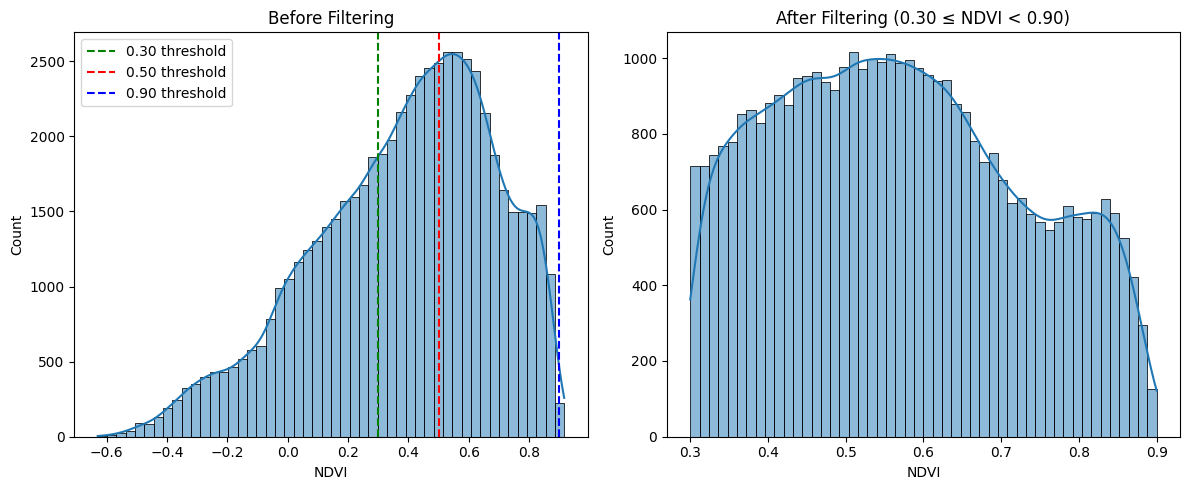

In [8]:
plt.figure(figsize=(12, 5))

# Before filtering
plt.subplot(1, 2, 1)
sns.histplot(Extract["NDVI"], bins=50, kde=True)
plt.axvline(0.30, color="green",linestyle="--", label="0.30 threshold")
plt.axvline(0.50, color="red",linestyle="--", label="0.50 threshold")
plt.axvline(0.90, color="blue",linestyle="--", label="0.90 threshold")
plt.title("Before Filtering")
plt.xlabel("NDVI")
plt.legend()

# After filtering
plt.subplot(1, 2, 2)
sns.histplot(df_veg["NDVI"], bins=50, kde=True)
plt.title("After Filtering (0.30 ≤ NDVI < 0.90)")
plt.xlabel("NDVI")

plt.tight_layout()
plt.show()

# Clean data from noise usig Isolation Forest (IF)

Number of band columns: 55
Clean shape: (30816, 61)
Anomalous shape: (7704, 61)
Anomaly %: 20.0


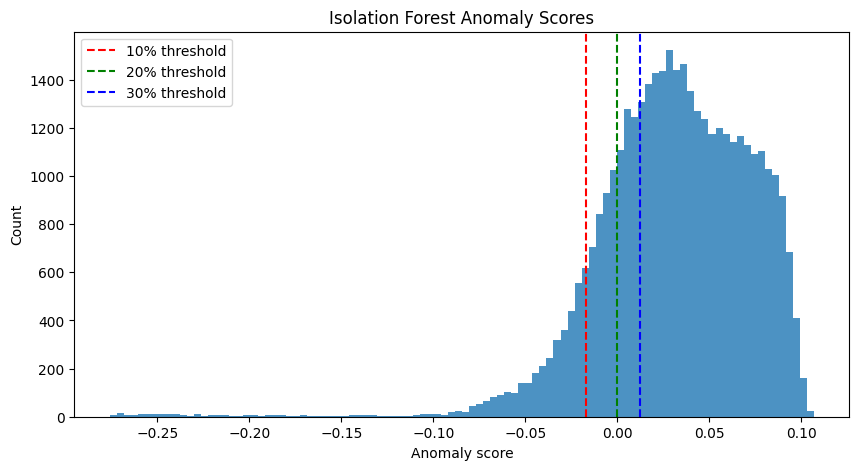

In [9]:
# Select HSI band columns
band_cols = [c for c in df_veg.columns if c.startswith("Band_")]
print("Number of band columns:", len(band_cols))

X = df_veg[band_cols].values

# Isolation Forest for anomaly detection
iso = IsolationForest(
    n_estimators=200,
    contamination=0.2,
    random_state=42)

df_veg["anomaly_flag"] = iso.fit_predict(X)   # 1 = normal, -1 = anomaly
df_veg["anomaly_score"] = iso.decision_function(X)

# Split clean vs anomalous pixels
df_clean = df_veg[df_veg["anomaly_flag"] == 1].copy()
df_anom = df_veg[df_veg["anomaly_flag"] == -1].copy()

print("Clean shape:", df_clean.shape)
print("Anomalous shape:", df_anom.shape)
print("Anomaly %:", round(len(df_anom) / len(df_veg) * 100, 2))

# Visual comparison: anomaly score distribution
threshold_1 = np.percentile(df_veg["anomaly_score"], 10)
threshold_10 = np.percentile(df_veg["anomaly_score"], 20)
threshold_30 = np.percentile(df_veg["anomaly_score"], 30)

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(df_veg["anomaly_score"], bins=100, alpha=0.8)
plt.axvline(threshold_1, linestyle="--", color="r", label="10% threshold")
plt.axvline(threshold_10, linestyle="--", color="g", label="20% threshold")
plt.axvline(threshold_30, linestyle="--", color="b", label="30% threshold")
plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.legend()
plt.show()

In [10]:
# palette = ['#ff7f0e', '#1f77b4']
# anomaly_inputs = band_cols[::20]

# # Create readable labels
# df_veg['anomaly_label'] = df_veg['anomaly_flag'].map({
#     -1: 'Anomalous',
#      1: 'Normal'
# })

# g = sns.pairplot(
#     df_veg,
#     vars=anomaly_inputs,
#     hue='anomaly_label',
#     palette=palette
# )

# g._legend.set_title("Anomaly Flag")

In [11]:
# See which rows were flagged as anomalies
df_anom.head()

,Data_modality,Treatment,Plot_ID,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,...,Band_49,Band_50,Band_51,Band_52,Band_53,Band_54,Band_55,NDVI,anomaly_flag,anomaly_score
0,Training,D0,1001,20.5167,25.0316,21.8547,23.5877,26.3541,25.7957,34.5476,...,42.5904,83.8001,146.0350,71.2619,280.2890,157.347,153.530,0.608245,-1,-0.266193
1,Training,D0,1001,21.9964,23.5298,22.4497,24.1533,26.0847,26.2331,42.9715,...,47.1831,72.5367,122.5820,56.5421,233.9130,165.023,149.644,0.627123,-1,-0.259300
2,Training,D0,1001,23.1539,26.6293,22.6305,25.6818,27.0141,27.7929,50.9260,...,51.5762,63.3694,108.2040,48.8815,150.6220,184.805,148.170,0.630295,-1,-0.254220
3,Training,D0,1001,22.9469,25.5629,25.9113,25.0950,27.5144,29.0197,61.0427,...,49.4895,52.0720,101.0490,47.7884,90.9510,230.240,147.683,0.606519,-1,-0.238712
4,Training,D0,1001,26.6236,28.3348,28.2202,28.4605,29.3087,34.6130,68.1338,...,50.7099,51.3292,98.0601,52.6824,64.8777,300.332,153.585,0.644853,-1,-0.234234


In [12]:
# Calculate CV (Std / Mean) for each band
cv_before = (df_veg[band_cols].std() / df_veg[band_cols].mean())
cv_after = (df_clean[band_cols].std() / df_clean[band_cols].mean())

# Create a summary table
stats_comparison = pd.DataFrame({
    'Metric': ['Mean CV (%)', 'Max CV (%)', 'Total Variance'],
    'Before Cleaning': [cv_before.mean()*100, cv_before.max()*100, df_veg[band_cols].var().sum()],
    'After Cleaning': [cv_after.mean()*100, cv_after.max()*100, df_clean[band_cols].var().sum()]
})

stats_comparison['Improvement (%)'] = ((stats_comparison['Before Cleaning'] - stats_comparison['After Cleaning']) / stats_comparison['Before Cleaning']) * 100
print(stats_comparison)

           Metric  Before Cleaning  After Cleaning  Improvement (%)
0     Mean CV (%)        52.162077       45.161794        13.420253
1      Max CV (%)        72.487544       59.242417        18.272279
2  Total Variance     17202.924714    12590.427013        26.812288


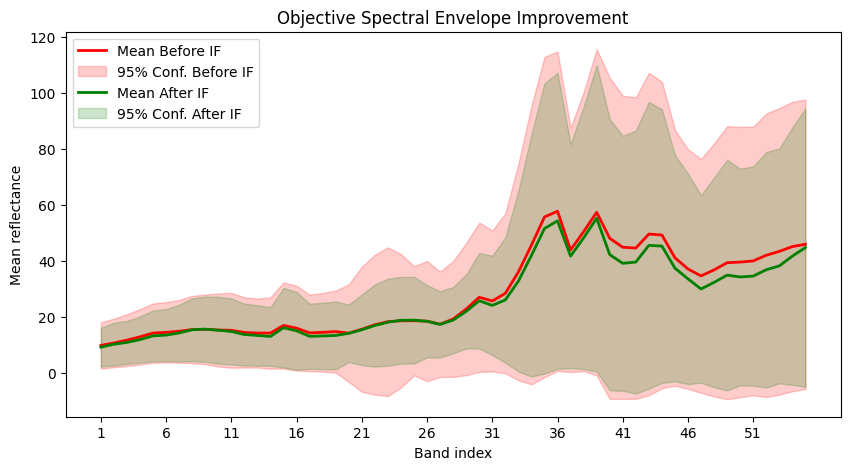

In [13]:
plt.figure(figsize=(10, 5))

def plot_envelope(df, color, label):
    mu = df[band_cols].mean()
    sigma = df[band_cols].std()
    plt.plot(mu, color=color, label=f'Mean {label}', linewidth=2)
    plt.fill_between(range(len(mu)), mu - 2*sigma, mu + 2*sigma, color=color, alpha=0.2, label=f'95% Conf. {label}')

plot_envelope(df_veg, 'red', 'Before IF')
plot_envelope(df_clean, 'green', 'After IF')

# Create numeric indices
ticks = range(0, 55, 5) 
labels = [i+1 for i in ticks]

plt.xticks(ticks=ticks, labels=labels)

plt.title("Objective Spectral Envelope Improvement")
plt.xlabel("Band index")
plt.ylabel("Mean reflectance")
plt.legend()
plt.show()

In [14]:
# Step 1: mean per Plot within each Treatment
rep_mean = (
    df_clean
    .groupby(["Data_modality", "Treatment", "Plot_ID"])[band_cols]
    .mean()
    .reset_index()
)

# Step 2: std across plots (replicates) within each Treatment
treatment_std = (
    rep_mean
    .groupby("Treatment")[band_cols]
    .std()
)

# Step 3: mean per Treatment (directly from raw data)
treatment_plot = (
    df_clean
    .groupby("Treatment")[band_cols]
    .mean()
)

treatment_plot

,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,...,Band_46,Band_47,Band_48,Band_49,Band_50,Band_51,Band_52,Band_53,Band_54,Band_55
Treatment,,,,,,,,,,,,,,,,,,,,,
D0,9.112523,10.237797,10.756596,11.753566,13.083894,13.297488,14.207807,15.559872,15.887986,15.478975,...,32.411871,29.655846,32.110817,34.727611,34.025324,33.745592,35.740271,37.132970,40.744201,44.069650
D1,9.707623,10.818305,11.314025,12.214991,13.510986,13.744678,14.520297,16.049159,16.343787,15.874952,...,32.716963,28.695710,31.298201,33.944942,32.951996,32.948123,34.953587,36.412455,40.788729,44.809960
D3,8.820918,9.911812,10.505248,11.421849,12.695900,13.071457,13.880758,14.930921,15.091290,14.655096,...,34.405670,30.304436,32.913442,35.595513,34.627086,34.724234,37.118473,39.158824,43.478082,46.675638
D5,9.211661,10.201268,11.133013,12.313617,13.673115,13.995660,14.548848,15.230047,15.328148,15.055820,...,34.769534,31.195798,33.031989,35.418764,35.388032,36.851995,39.459796,40.141898,41.910355,43.708716


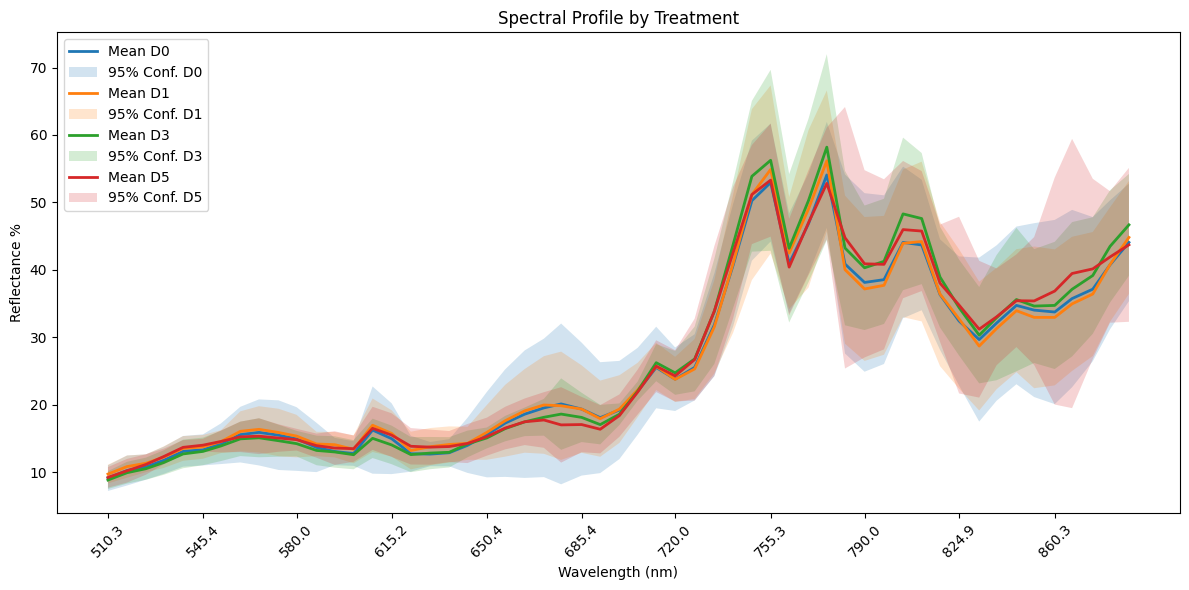

In [15]:
wavelengths = [
    510.318, 517.388, 524.359, 530.954, 538.096, 545.442, 552.092, 559.260,
    566.134, 573.395, 580.039, 587.418, 594.136, 601.118, 608.139, 615.179,
    622.282, 629.431, 636.461, 643.233, 650.386, 657.145, 664.373, 671.460,
    677.836, 685.410, 692.285, 699.391, 706.114, 712.980, 719.977, 727.202,
    734.460, 741.405, 748.347, 755.273, 762.124, 769.287, 776.040, 782.768,
    789.996, 797.178, 804.226, 811.110, 817.892, 824.930, 832.369, 838.806,
    846.136, 852.686, 860.294, 866.710, 874.352, 880.735, 887.727]
plt.figure(figsize=(12, 6))

for treatment in treatment_plot.index:
    mean_vals = treatment_plot.loc[treatment]
    std_vals = treatment_std.loc[treatment]

    # Line (Mean)
    plt.plot(
        wavelengths,
        mean_vals,
        linewidth=2,
        label=f"Mean {treatment}"
    )

    # Shaded area (95% confidence ≈ ±2 std)
    plt.fill_between(
        wavelengths,
        mean_vals - 2*std_vals,
        mean_vals + 2*std_vals,
        alpha=0.2,
        label=f"95% Conf. {treatment}"
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance %")
plt.title("Spectral Profile by Treatment")

plt.legend(loc='upper left', fontsize=10)

# plt.xticks(range(1, len(band_index)+1, 5))
plt.xticks(wavelengths[::5], rotation=45)

plt.tight_layout()
plt.show()

# Coefficient of Variation (CV) per wavelength

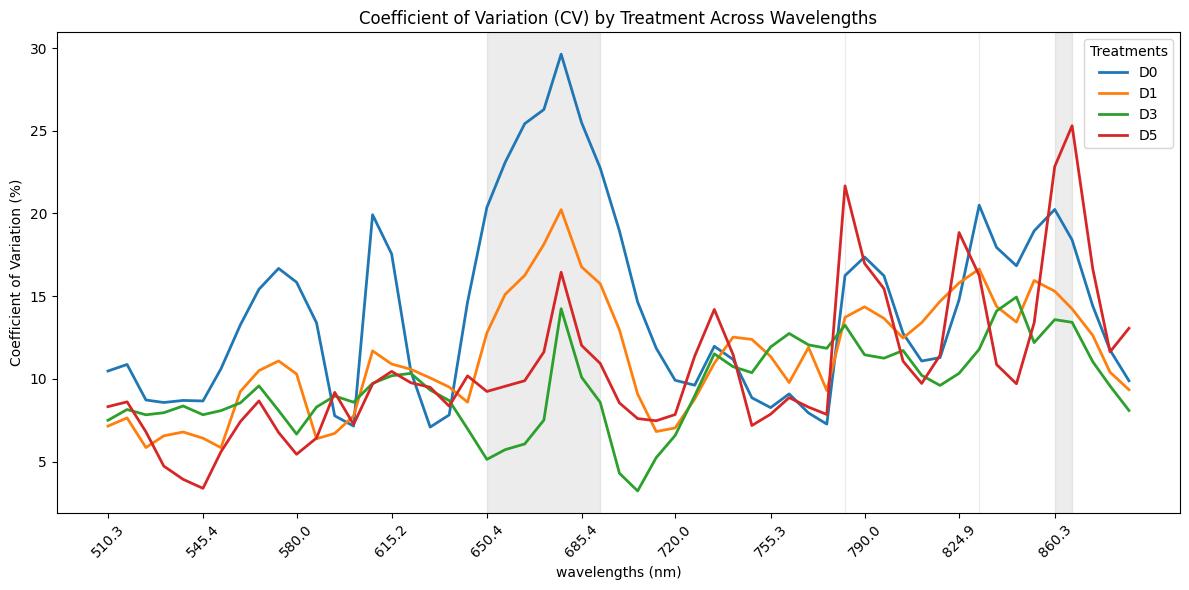

In [16]:
# CV (%) per treatment and wavelength
cv_df = (treatment_std / treatment_plot) * 100

# Threshold for highlighting
threshold = 20

plt.figure(figsize=(12, 6))

for treatment in cv_df.index:
    plt.plot(wavelengths, cv_df.loc[treatment].values, label=str(treatment), linewidth=2)

# Bands where ANY treatment exceeds the threshold
high_var_mask = (cv_df > threshold).any(axis=0).to_numpy()

# Highlight continuous high-variability regions
in_region = False
start = None

for i, flag in enumerate(high_var_mask):
    if flag and not in_region:
        start = wavelengths[i]
        in_region = True
    elif not flag and in_region:
        end = wavelengths[i - 1]
        plt.axvspan(start, end, color="grey", alpha=0.15)
        in_region = False

# Close final region
if in_region:
    plt.axvspan(start, wavelengths[-1], color="grey", alpha=0.15, label=f"CV > {threshold}% region")

plt.xlabel("wavelengths (nm)")
plt.ylabel("Coefficient of Variation (%)")
plt.title("Coefficient of Variation (CV) by Treatment Across Wavelengths")
plt.legend(title="Treatments")
plt.xticks(wavelengths[::5], rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Step 1: mean per Plot within each Treatment
rep_mean_veg = (
    df_veg
    .groupby(["Data_modality", "Treatment", "Plot_ID"])[band_cols]
    .mean()
    .reset_index()).copy()

# Step 2: std across plots (replicates) within each Treatment
treatment_std_veg = (
    rep_mean
    .groupby("Treatment")[band_cols]
    .std()).copy()

# Step 3: mean per Treatment (directly from raw data)
treatment_veg = (
    df_veg
    .groupby("Treatment")[band_cols]
    .mean()).copy()

treatment_veg

,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,...,Band_46,Band_47,Band_48,Band_49,Band_50,Band_51,Band_52,Band_53,Band_54,Band_55
Treatment,,,,,,,,,,,,,,,,,,,,,
D0,10.269162,11.182040,12.159704,13.383394,14.740232,14.926049,15.381249,16.037224,16.131737,15.969538,...,37.069591,33.935719,36.125164,38.761769,38.872496,39.218654,41.635882,43.118354,44.610223,45.110081
D1,10.339652,11.180080,12.232517,13.456497,14.796748,15.011638,15.203575,15.937365,16.044686,15.797326,...,36.638923,34.055880,36.474855,39.080243,39.055655,39.239148,41.187461,42.271406,44.461080,46.130718
D3,9.100593,10.028277,10.874607,11.946911,13.220424,13.547701,14.059469,14.796065,14.879960,14.549931,...,37.976713,35.641615,38.099135,40.822013,40.815795,40.696129,42.197642,44.444382,47.225505,48.327757
D5,9.574674,10.456974,11.567102,12.831191,14.185703,14.501971,14.839182,15.193519,15.215567,15.019674,...,36.818237,35.090522,36.595711,38.911258,39.740972,40.995290,43.180222,43.915408,44.317871,44.284312


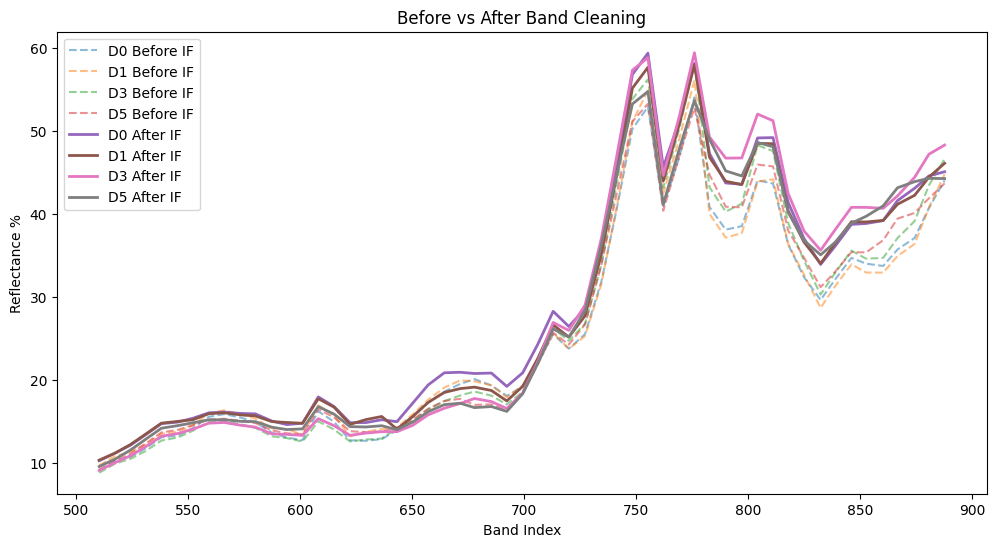

In [18]:
plt.figure(figsize=(12,6))

# Before
plt.plot(wavelengths, treatment_plot.loc["D0"], label="D0 Before IF", alpha=0.5, linestyle="--")
plt.plot(wavelengths, treatment_plot.loc["D1"], label="D1 Before IF", alpha=0.5, linestyle="--")
plt.plot(wavelengths, treatment_plot.loc["D3"], label="D3 Before IF", alpha=0.5, linestyle="--")
plt.plot(wavelengths, treatment_plot.loc["D5"], label="D5 Before IF", alpha=0.5, linestyle="--")

# After
plt.plot(wavelengths, treatment_veg.loc["D0"], label="D0 After IF", linewidth=2)
plt.plot(wavelengths, treatment_veg.loc["D1"], label="D1 After IF", linewidth=2)
plt.plot(wavelengths, treatment_veg.loc["D3"], label="D3 After IF", linewidth=2)
plt.plot(wavelengths, treatment_veg.loc["D5"], label="D5 After IF", linewidth=2)

plt.xlabel("Band Index")
plt.ylabel("Reflectance %")
plt.legend()
plt.title("Before vs After Band Cleaning")
plt.show()

# Variance comparison: Visible vs NIR

In [19]:
# Define regions
# Convert to numpy for masking
wavelengths_np = np.array(wavelengths)

visible_mask = (wavelengths_np >= 500) & (wavelengths_np < 700)
nir_mask     = (wavelengths_np >= 700) & (wavelengths_np <= 900)

# Compute average variance per region
# Square of std = variance
variance_df = treatment_std ** 2

region_variance = []

for treatment in variance_df.index:
    var_values = variance_df.loc[treatment].values
    
    visible_var_mean = np.mean(var_values[visible_mask])
    nir_var_mean     = np.mean(var_values[nir_mask])
    
    region_variance.append({
        "Treatment": treatment,
        "Visible Variance": visible_var_mean,
        "NIR Variance": nir_var_mean
    })

region_variance_df = pd.DataFrame(region_variance)
print(region_variance_df)

  Treatment  Visible Variance  NIR Variance
0        D0          8.084130     25.051599
1        D1          3.819842     22.751887
2        D3          1.532133     21.277229
3        D5          1.892178     28.754769


 # Test differences between treatments
 ## ANOVA on spectral regions

In [20]:
from scipy.stats import f_oneway

# Define regions
regions = {
    "Visible_500_700": (wavelengths_np >= 500) & (wavelengths_np < 700),
    "RedEdge_700_740": (wavelengths_np >= 700) & (wavelengths_np < 740),
    "NIR_740_820":     (wavelengths_np >= 740) & (wavelengths_np < 820),
}

# Compute mean reflectance per region per sample
region_data = []

for i, row in rep_mean.iterrows():
# for i, row in rep_mean.iterrows():
    entry = {"Treatment": row["Treatment"]}
    
    # values = row[clean_band_cols].values.astype(float)
    values = row[band_cols].values.astype(float)

    for region_name, mask in regions.items():
        entry[region_name] = np.nanmean(values[mask])

    region_data.append(entry)

region_df = pd.DataFrame(region_data)

# Run ANOVA per region
for region in regions.keys():
    groups = [
        region_df[region_df["Treatment"] == t][region].dropna()
        for t in region_df["Treatment"].unique()
    ]
    
    stat, p = f_oneway(*groups)
    print(f"{region}: F = {stat:.4f}, p = {p:.4f}")

Visible_500_700: F = 1.1066, p = 0.3591
RedEdge_700_740: F = 0.6434, p = 0.5922
NIR_740_820: F = 1.4870, p = 0.2344


In [21]:
region_df.head()

,Treatment,Visible_500_700,RedEdge_700_740,NIR_740_820
0,D0,18.830550,29.657749,43.517235
1,D0,16.724558,25.876529,41.526800
2,D0,16.744617,28.691442,45.126952
3,D0,14.680628,25.175955,44.887957
4,D0,14.121698,22.140129,37.516147


# PCA

In [22]:
# 1) Split dataset
train_df = rep_mean[rep_mean["Data_modality"] == "Training"]
val_df   = rep_mean[rep_mean["Data_modality"] == "Validation"]

# Extract spectral data
X_train = train_df[band_cols].values.astype(float)
X_val   = val_df[band_cols].values.astype(float)

# Labels
y_train = train_df["Treatment"].values
y_val   = val_df["Treatment"].values

# 2) Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit here
X_val_scaled   = scaler.transform(X_val)         # apply same scaling
# “Spectral data were mean-centered and scaled to unit variance using parameters derived from the training dataset.”

# 3) PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)

# 4) Variance explained
explained_variance = pca.explained_variance_ratio_
cum_variance = np.cumsum(explained_variance)

# Print first components
for i, var in enumerate(explained_variance[:10]):
    print(f"PC{i+1}: {var:.4f} ({cum_variance[i]:.4f} cumulative)")

PC1: 0.3691 (0.3691 cumulative)
PC2: 0.2569 (0.6260 cumulative)
PC3: 0.1876 (0.8136 cumulative)
PC4: 0.0672 (0.8808 cumulative)
PC5: 0.0360 (0.9168 cumulative)
PC6: 0.0233 (0.9401 cumulative)
PC7: 0.0192 (0.9593 cumulative)
PC8: 0.0147 (0.9740 cumulative)
PC9: 0.0091 (0.9831 cumulative)
PC10: 0.0054 (0.9885 cumulative)


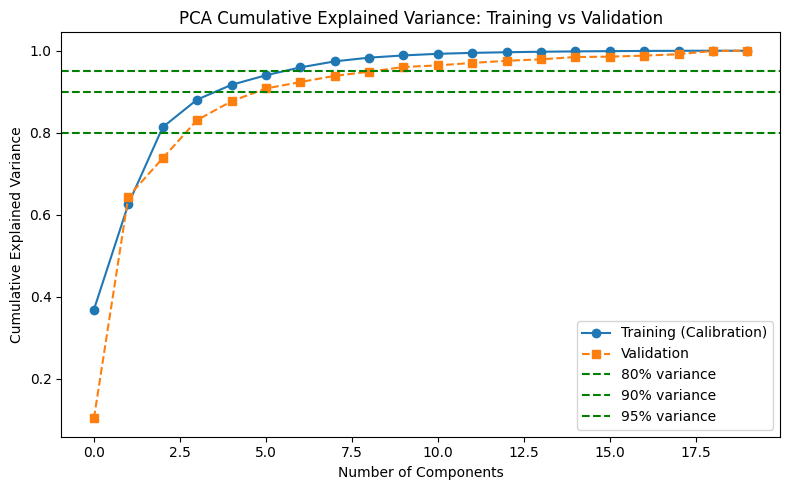

In [23]:
# --- Training cumulative variance (standard) ---
explained_variance_train = pca.explained_variance_ratio_
cum_variance_train = np.cumsum(explained_variance_train)

# --- Validation variance projected onto training PCs ---
# variance of each PC in validation set
val_var = np.var(X_val_pca, axis=0)

# normalize to total variance in validation set
val_var_ratio = val_var / np.sum(val_var)
cum_variance_val = np.cumsum(val_var_ratio)

# --- Plot both ---
plt.figure(figsize=(8,5))

plt.plot(cum_variance_train, marker='o', label="Training (Calibration)")
plt.plot(cum_variance_val, marker='s', linestyle='--', label="Validation")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance: Training vs Validation")

plt.axhline(0.80, linestyle='--', label="80% variance", color='green')
plt.axhline(0.90, linestyle='--', label="90% variance", color='green')
plt.axhline(0.95, linestyle='--', label="95% variance", color='green')

plt.legend()
plt.tight_layout()
plt.show()

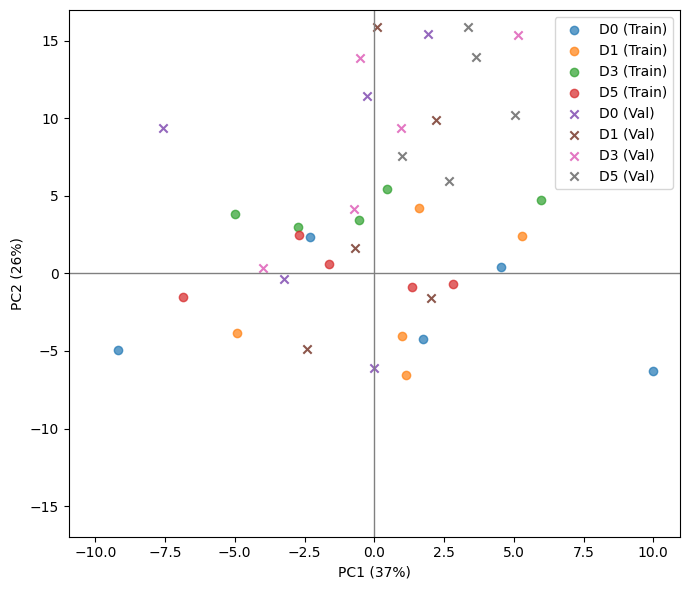

In [24]:
plt.figure(figsize=(7,6))

# Training
for t in np.unique(y_train):
    mask = y_train == t
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=f"{t} (Train)",
        alpha=0.7
    )

# Validation
for t in np.unique(y_val):
    mask = y_val == t
    plt.scatter(
        X_val_pca[mask, 0],
        X_val_pca[mask, 1],
        marker='x',
        label=f"{t} (Val)"
    )

plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

xlim = plt.xlim()
ylim = plt.ylim()

max_x = max(abs(xlim[0]), abs(xlim[1]))
max_y = max(abs(ylim[0]), abs(ylim[1]))

plt.xlim(-max_x, max_x)
plt.ylim(-max_y, max_y)

plt.xlabel("PC1 (37%)")
plt.ylabel("PC2 (26%)")
# plt.title("PCA: Training vs Validation")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# 7) Number of components needed
n_80 = np.argmax(cum_variance >= 0.80) + 1
n_90 = np.argmax(cum_variance >= 0.90) + 1
n_95 = np.argmax(cum_variance >= 0.95) + 1

print(f"Components for 80% variance: {n_80}")
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")

Components for 80% variance: 3
Components for 90% variance: 5
Components for 95% variance: 7



Training metrics
Accuracy : 0.8500
Precision: 0.8542
Recall   : 0.8500
F1-score : 0.8485

Classification report:
              precision    recall  f1-score   support

          D0       1.00      1.00      1.00         5
          D1       0.75      0.60      0.67         5
          D3       1.00      1.00      1.00         5
          D5       0.67      0.80      0.73         5

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20


Validation metrics
Accuracy : 0.3000
Precision: 0.1623
Recall   : 0.3000
F1-score : 0.2083

Classification report:
              precision    recall  f1-score   support

          D0       0.00      0.00      0.00         5
          D1       0.00      0.00      0.00         5
          D3       0.36      0.80      0.50         5
          D5       0.29      0.40      0.33         5

    accuracy                           0.30        20
   macro 

C:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


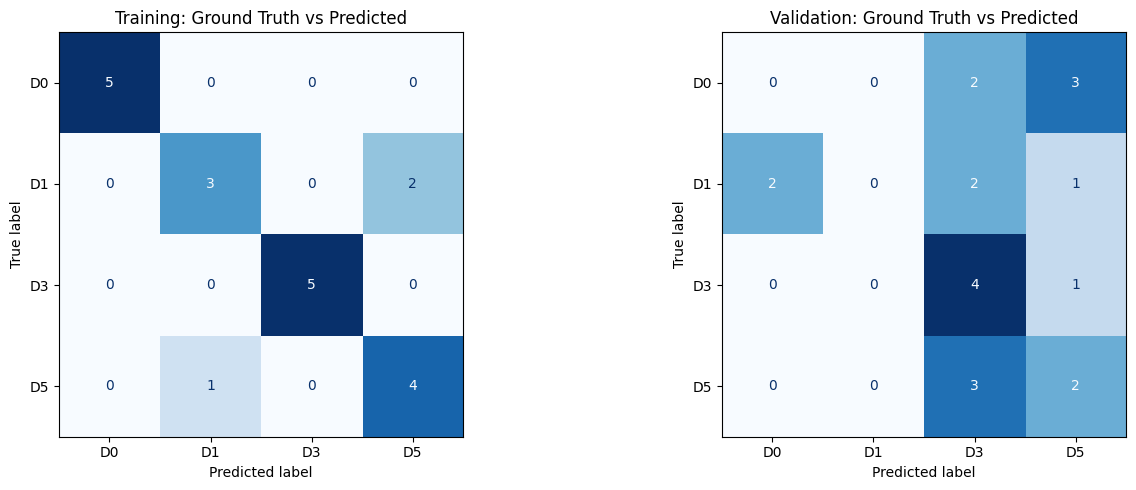

In [26]:
# 1) Choose how many PCs to use
n_keep = n_90

X_train_pca_sel = X_train_pca[:, :n_keep]
X_val_pca_sel   = X_val_pca[:, :n_keep]

# 2) Train a classifier
clf = LogisticRegression(max_iter=5000, multi_class="multinomial", random_state=42)
clf.fit(X_train_pca_sel, y_train)

# 3) Predict train and validation
y_train_pred = clf.predict(X_train_pca_sel)
y_val_pred   = clf.predict(X_val_pca_sel)

# 4) Metrics function
def print_metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    print(f"\n{name} metrics")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

# Print metrics
print_metrics(y_train, y_train_pred, "Training")
print_metrics(y_val, y_val_pred, "Validation")

# -----------------------------
# 5) Confusion matrices
# -----------------------------
labels = np.unique(np.concatenate([y_train, y_val]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_val   = confusion_matrix(y_val, y_val_pred, labels=labels)

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels)
disp_val   = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels)

disp_train.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Training: Ground Truth vs Predicted")

disp_val.plot(ax=axes[1], cmap="Blues", colorbar=False, values_format="d")
axes[1].set_title("Validation: Ground Truth vs Predicted")

plt.tight_layout()
plt.show()

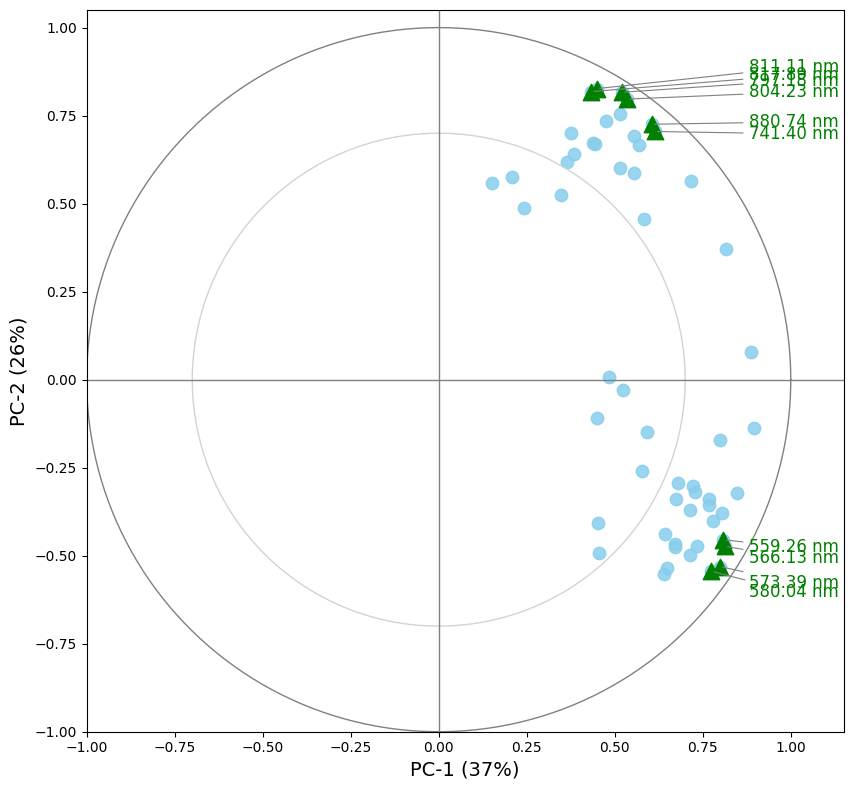

In [27]:
# correlation loadings
corr_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings = pd.DataFrame(
    corr_loadings,
    index=wavelengths,
    columns=[f"PC{i+1}" for i in range(corr_loadings.shape[1])]
)

# top 10 by magnitude in PC1/PC2
loadings["magnitude"] = np.sqrt(loadings["PC1"]**2 + loadings["PC2"]**2)
top10 = loadings.nlargest(10, "magnitude").copy()

fig, ax = plt.subplots(figsize=(12, 8))

# all bands
ax.scatter(loadings["PC1"], loadings["PC2"], s=80, color="skyblue", alpha=0.85)

# top 10
ax.scatter(top10["PC1"], top10["PC2"], s=140, marker="^", color="green", zorder=3)

# sort top 10 by PC2 so labels don't stack
top10 = top10.sort_values("PC2", ascending=False)

# put labels to the right in a vertical rail
x_text = 0.88
y_offsets = np.linspace(0.06, -0.06, len(top10))

for (band, row), dy in zip(top10.iterrows(), y_offsets):
    label = f"{band:.2f} nm" if isinstance(band, (float, np.floating)) else str(band)

    ax.annotate(
        label,
        xy=(row["PC1"], row["PC2"]),              # point
        xytext=(x_text, row["PC2"] + dy),          # label position
        textcoords="data",
        fontsize=12,
        color="green",
        ha="left",
        va="center",
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
        zorder=4
    )

# circles
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), color="gray", lw=1)
ax.plot(0.7 * np.cos(theta), 0.7 * np.sin(theta), color="lightgray", lw=1)

# axes
ax.axhline(0, color="gray", lw=1)
ax.axvline(0, color="gray", lw=1)

ax.set_xlim(-1, 1.15)   # extra room on the right for labels
ax.set_ylim(-1, 1.05)
ax.set_aspect("equal", adjustable="box")

pc1_pct = pca.explained_variance_ratio_[0] * 100
pc2_pct = pca.explained_variance_ratio_[1] * 100

ax.set_xlabel(f"PC-1 ({pc1_pct:.0f}%)", fontsize=14)
ax.set_ylabel(f"PC-2 ({pc2_pct:.0f}%)", fontsize=14)
# ax.set_title("Correlation Loadings (X)", fontsize=18, weight="bold")

plt.tight_layout()
plt.show()

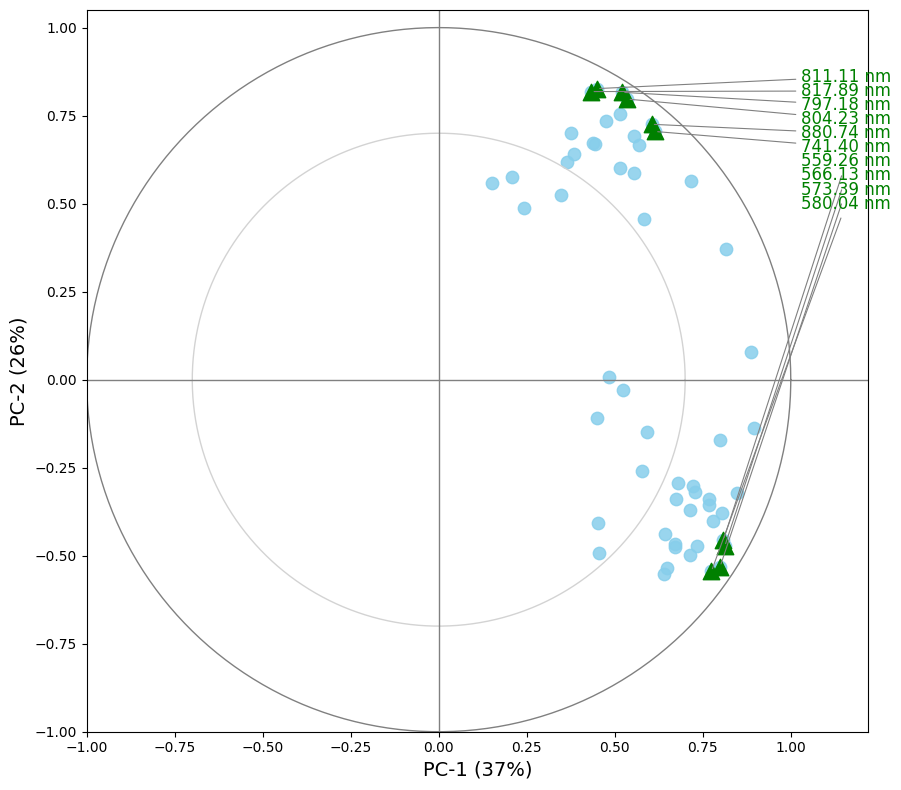

In [28]:
from matplotlib.patches import Circle
import numpy as np

# sort top 10 by PC2 so labels go from top to bottom
top10 = top10.sort_values("PC2", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

# all bands
ax.scatter(loadings["PC1"], loadings["PC2"], s=80, color="skyblue", alpha=0.85)

# top 10
ax.scatter(top10["PC1"], top10["PC2"], s=140, marker="^", color="green", zorder=3)

# circles
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), color="gray", lw=1)
ax.plot(0.7 * np.cos(theta), 0.7 * np.sin(theta), color="lightgray", lw=1)

# axes
ax.axhline(0, color="gray", lw=1)
ax.axvline(0, color="gray", lw=1)

# label rail on the right
x_text = 1.03
y_texts = np.linspace(0.86, 0.50, len(top10))   # more separation

for (band, row), y in zip(top10.iterrows(), y_texts):
    label = f"{band:.2f} nm" if isinstance(band, (float, np.floating)) else str(band)

    ax.annotate(
        label,
        xy=(row["PC1"], row["PC2"]),
        xytext=(x_text, y),
        textcoords="data",
        fontsize=12,
        color="green",
        ha="left",
        va="center",
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
        zorder=4
    )

ax.set_xlim(-1, 1.22)
ax.set_ylim(-1, 1.05)
ax.set_aspect("equal", adjustable="box")

pc1_pct = pca.explained_variance_ratio_[0] * 100
pc2_pct = pca.explained_variance_ratio_[1] * 100
ax.set_xlabel(f"PC-1 ({pc1_pct:.0f}%)", fontsize=14)
ax.set_ylabel(f"PC-2 ({pc2_pct:.0f}%)", fontsize=14)

plt.tight_layout()
plt.show()

In [29]:
# Check accuracy (train vs validation)
from sklearn.metrics import accuracy_score

print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Val accuracy:", accuracy_score(y_val, y_val_pred))

Train accuracy: 0.85
Val accuracy: 0.3


In [30]:
# Check class balance
print(train_df["Treatment"].value_counts())
print(val_df["Treatment"].value_counts())

Treatment
D0    5
D1    5
D3    5
D5    5
Name: count, dtype: int64
Treatment
D0    5
D1    5
D3    5
D5    5
Name: count, dtype: int64


# PCA Compute loadings

In [31]:
# To check how many PCs you actually have:
print(pca.components_.shape)
print(pca.n_components_)

(20, 55)
20


In [32]:
# 3) Identify most influential wavelengths
# PC1 (most influential overall variation)
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10)
print("Top PC1 wavelengths:\n", top_pc1)

Top PC1 wavelengths:
 712.980    0.895963
719.977    0.885707
706.114    0.846552
727.202    0.814843
566.134    0.812450
559.260    0.808841
699.391    0.805353
573.395    0.799344
643.233    0.797860
587.418    0.779857
Name: PC1, dtype: float64


In [33]:
# PC2 (secondary variation — often more related to subtle differences)
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(10)
print("Top PC2 wavelengths:\n", top_pc2)

Top PC2 wavelengths:
 811.110    0.826739
817.892    0.818300
797.178    0.816262
804.226    0.796911
789.996    0.755710
824.930    0.733649
880.735    0.725391
741.405    0.704959
748.347    0.700075
874.352    0.692187
Name: PC2, dtype: float64


In [34]:
important_wavelengths = pd.concat([
    loadings["PC1"].abs(),
    loadings["PC2"].abs()
], axis=1)

important_wavelengths["combined"] = important_wavelengths.mean(axis=1)

top_combined = important_wavelengths["combined"].sort_values(ascending=False).head(10)
print("Top combined wavelengths:\n",top_combined)

Top combined wavelengths:
 797.178    0.668478
804.226    0.666536
573.395    0.665115
880.735    0.664998
741.405    0.659585
580.039    0.659449
566.134    0.642810
734.460    0.640209
811.110    0.638173
789.996    0.635161
Name: combined, dtype: float64


# Variability and Data Quality Evaluate

## 1) Presence of outliers
A) Visual check (boxplots per band or PCA space)
PCA-based outlier detection

In [35]:
import numpy as np

# Distance from center in PCA space (PC1 & PC2)
dist = np.sqrt(X_train_pca[:, 0]**2 + X_train_pca[:, 1]**2)

# Threshold (e.g., top 5%)
threshold = np.percentile(dist, 95)

outliers = dist > threshold

print(f"Number of outliers: {np.sum(outliers)}")

Number of outliers: 1


### Plot outliers

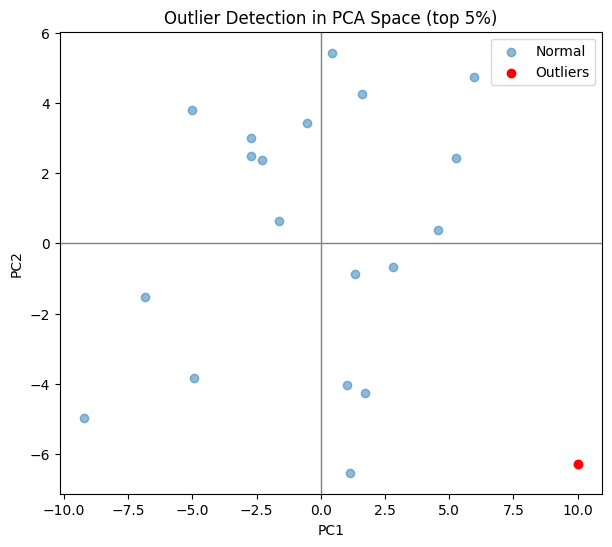

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(X_train_pca[:,0], X_train_pca[:,1], alpha=0.5, label="Normal")
plt.scatter(X_train_pca[outliers,0], X_train_pca[outliers,1], 
            color='red', label="Outliers")

plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

xlim = plt.xlim()
ylim = plt.ylim()

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("Outlier Detection in PCA Space (top 5%)")
plt.show()

## 2) Variability within treatment groups

### A) CV summary per treatment

In [37]:
cv_df = (treatment_std / treatment_plot) * 100

cv_summary = cv_df.mean(axis=1)
print(cv_summary)

Treatment
D0    14.267881
D1    11.413078
D3     9.509184
D5    10.608380
dtype: float64


## 3) Consistency of spectral responses under stress

In [38]:
# # B) Quantify consistency (correlation within treatment)

for t in df_clean["Treatment"].unique():
    subset = df_clean[df_clean["Treatment"] == t][band_cols]
    corr_matrix = subset.T.corr()
    
    # remove diagonal
    mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
    mean_corr = corr_matrix.where(mask).mean().mean()
    
    print(f"{t}: mean correlation (no self) = {mean_corr:.3f}")

D0: mean correlation (no self) = 0.528
D1: mean correlation (no self) = 0.521
D3: mean correlation (no self) = 0.553
D5: mean correlation (no self) = 0.560
